# XGBoost Multiclass Classification Model — 15 Stocks

This corrected notebook addresses the presentation feedback by using XGBoost as a tree-based classifier for stock direction instead of using a regression output and then forcing it into a binary up/down label.

Main corrections:
- Uses `XGBClassifier`, not `XGBRegressor`, for directional prediction.
- Converts future 7-day return into three classes: Down, Neutral, and Up.
- Uses thresholds so very small near-zero returns are not treated as meaningful Buy/Avoid signals.
- Compares model performance against naive baselines such as always predicting Up or the majority class.
- Uses macro F1 and balanced accuracy so accuracy is not misleading when one class dominates.

## 1. Import Libraries

This section imports the libraries needed for data cleaning, feature engineering, XGBoost modeling, evaluation, and visualization.

In [1]:
# Import libraries for data handling
import pandas as pd
import numpy as np
from pathlib import Path

# Import visualization library
import matplotlib.pyplot as plt

# Import XGBoost multiclass classifier
from xgboost import XGBClassifier

# Import classification metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_sample_weight

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")


## Professor Feedback Fix

The previous notebook used `XGBRegressor` to predict a numeric 7-day return and then converted that value into an up/down class using a `> 0` rule. That created two problems:

1. Very small predicted returns close to zero were treated as real trading signals.
2. Directional accuracy could be misleading because a naive model that always predicts the dominant class, such as always predicting Up, can look strong.

The corrected approach below treats this as a **multiclass classification problem**:

- `0 = Down`: future 7-day return is below the negative threshold.
- `1 = Neutral`: future 7-day return is close to zero.
- `2 = Up`: future 7-day return is above the positive threshold.

For this notebook, the threshold is set to **±1% over 7 days**. You can change this value if your professor wants a different cutoff.


In [2]:
from pathlib import Path

# Project root folder on your local computer
PROJECT_ROOT = Path(
    r"C:\Users\POORVI NIDSOSHI\Desktop\Project-ML\group-project-algorithm-architects"
)

# Data folder inside the project
DATA_PATH = PROJECT_ROOT / "data"

# Check data path
print("DATA_PATH:", DATA_PATH)
print("Data path exists:", DATA_PATH.exists())
print("GSPC exists:", (DATA_PATH / "GSPC.csv").exists())
print("IXIC exists:", (DATA_PATH / "IXIC.csv").exists())
print("BA exists:", (DATA_PATH / "BA.csv").exists())

# Dictionary mapping stock tickers to CSV file names
stock_files = {
    "AAPL": "Apple.csv",
    "AMZN": "Amazon.csv",
    "GOOGL": "Google.csv",
    "MSFT": "MSFT.csv",
    "NVDA": "NVIDIA.csv",
    "BA": "BA.csv",
    "CVX": "CVX.csv",
    "GS": "GSach.csv",
    "JNJ": "JNJ.csv",
    "JPM": "JPM.csv",
    "META": "META.csv",
    "PFE": "PFE.csv",
    "TSLA": "TSLA.csv",
    "WMT": "WMT.csv",
    "XOM": "XOM.csv"
}

# Check number of stock datasets
print("Number of stock datasets:", len(stock_files))

# Check whether all files exist
missing_files = []

for ticker, file_name in stock_files.items():
    file_path = DATA_PATH / file_name

    if not file_path.exists():
        missing_files.append((ticker, file_name))

print("Missing files:", missing_files)

DATA_PATH: C:\Users\POORVI NIDSOSHI\Desktop\Project-ML\group-project-algorithm-architects\data
Data path exists: True
GSPC exists: True
IXIC exists: True
BA exists: True
Number of stock datasets: 15
Missing files: []


## 3. Helper Functions

These helper functions clean the data and create features.

The CSV files contain values such as `6,278,100`, so numeric columns are cleaned by removing commas before converting to numbers.

In [3]:
def clean_numeric_column(series):
    """
    Convert comma-formatted text numbers into numeric values.
    Example: "6,278,100" becomes 6278100.
    """
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )


def parse_date_column(series):
    """
    Convert date values into datetime format.
    The stock CSV files use formats like 2/27/2026.
    """
    parsed = pd.to_datetime(series, format="%m/%d/%Y", errors="coerce")
    if parsed.isna().mean() > 0.5:
        parsed = pd.to_datetime(series, errors="coerce")
    return parsed


def calculate_rsi(series, window=14):
    """
    Calculate Relative Strength Index (RSI).
    RSI is a momentum indicator used to identify strength of price movement.
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def load_stock_csv(file_path):
    """
    Load one stock CSV file and clean column names.
    """
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.replace(' ', '', regex=False).str.strip()
    return df

## 4. Feature Engineering Function

The feature engineering function creates the same type of time-series features used in the earlier XGBoost work:

- lagged close prices
- daily, weekly, and monthly returns
- moving averages
- volatility
- volume changes
- RSI
- calendar features
- future 7-day return target

The target variable is `target_7d_return`.

In [4]:
def classify_7d_return(return_value, threshold=0.01):
    """
    Convert a future 7-day return into a multiclass label.

    0 = Down    : return <= -threshold
    1 = Neutral : -threshold < return < threshold
    2 = Up      : return >= threshold
    """
    if return_value <= -threshold:
        return 0
    elif return_value >= threshold:
        return 2
    else:
        return 1


def create_xgboost_features(df, threshold=0.01):
    """
    Create XGBoost features for one stock dataframe.
    The target is prepared as a multiclass label instead of direct regression.
    """
    # Copy dataframe to avoid modifying original data
    df = df.copy()

    # Clean column names
    df.columns = df.columns.str.replace(' ', '', regex=False).str.strip()

    # Convert Date column
    df["Date"] = parse_date_column(df["Date"])

    # Convert numeric columns
    numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = clean_numeric_column(df[col])

    # Remove invalid Date or Close rows
    df = df.dropna(subset=["Date", "Close"]).reset_index(drop=True)

    # Sort oldest to newest because the original CSVs are often newest to oldest
    df = df.sort_values("Date").reset_index(drop=True)

    # Lagged close price features
    df["close_lag_1"] = df["Close"].shift(1)
    df["close_lag_7"] = df["Close"].shift(7)
    df["close_lag_30"] = df["Close"].shift(30)

    # Return features
    df["return_1d"] = df["Close"].pct_change(1)
    df["return_7d"] = df["Close"].pct_change(7)
    df["return_30d"] = df["Close"].pct_change(30)

    # Moving averages
    df["ma_7"] = df["Close"].rolling(window=7).mean()
    df["ma_30"] = df["Close"].rolling(window=30).mean()
    df["ma_200"] = df["Close"].rolling(window=200).mean()

    # Volatility features
    df["volatility_7"] = df["return_1d"].rolling(window=7).std()
    df["volatility_30"] = df["return_1d"].rolling(window=30).std()

    # Volume features
    df["volume_change_1d"] = df["Volume"].pct_change(1)
    df["volume_ma_7"] = df["Volume"].rolling(window=7).mean()
    df["volume_ma_30"] = df["Volume"].rolling(window=30).mean()
    df["volume_ratio_30"] = df["Volume"] / df["volume_ma_30"]

    # RSI feature
    df["rsi_14"] = calculate_rsi(df["Close"], window=14)

    # Calendar features
    df["weekday"] = df["Date"].dt.weekday
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter

    # Future 7-day return, kept for interpretation and portfolio simulation
    df["target_7d_return"] = df["Close"].shift(-7) / df["Close"] - 1

    # Multiclass classification target
    df["target_return_class"] = df["target_7d_return"].apply(
        lambda x: classify_7d_return(x, threshold=threshold) if pd.notna(x) else np.nan
    )

    return df


## 5. Load Market Index Data

The model uses market context from:

- S&P 500 (`GSPC.csv`)
- Nasdaq (`IXIC.csv`)

These are converted into daily return features and merged with each stock by date.

In [5]:
# Load S&P 500 data
sp500_df = load_stock_csv(DATA_PATH / "GSPC.csv")
sp500_df["Date"] = parse_date_column(sp500_df["Date"])
sp500_df["Close"] = clean_numeric_column(sp500_df["Close"])
sp500_df = sp500_df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
sp500_df["sp500_return"] = sp500_df["Close"].pct_change()
sp500_df = sp500_df[["Date", "sp500_return"]]

# Load Nasdaq data
nasdaq_df = load_stock_csv(DATA_PATH / "IXIC.csv")
nasdaq_df["Date"] = parse_date_column(nasdaq_df["Date"])
nasdaq_df["Close"] = clean_numeric_column(nasdaq_df["Close"])
nasdaq_df = nasdaq_df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
nasdaq_df["nasdaq_return"] = nasdaq_df["Close"].pct_change()
nasdaq_df = nasdaq_df[["Date", "nasdaq_return"]]

print("S&P 500 rows:", len(sp500_df))
print("Nasdaq rows:", len(nasdaq_df))
print("S&P 500 date range:", sp500_df["Date"].min(), "to", sp500_df["Date"].max())
print("Nasdaq date range:", nasdaq_df["Date"].min(), "to", nasdaq_df["Date"].max())

S&P 500 rows: 2805
Nasdaq rows: 2805
S&P 500 date range: 2015-01-02 00:00:00 to 2026-02-27 00:00:00
Nasdaq date range: 2015-01-02 00:00:00 to 2026-02-27 00:00:00


## 6. Train XGBoost Models for All 15 Stocks

This section follows the LSTM-style loop approach.

For each stock:

1. Load CSV file
2. Create features
3. Merge S&P 500 and Nasdaq returns
4. Split into train, validation, and test sets using time order
5. Train an XGBoost regressor
6. Predict future 7-day return
7. Store predictions and metrics

A separate XGBoost model is trained for each stock, but all predictions are combined into one final dataframe.

In [6]:
# Define feature columns used by XGBoost
feature_cols = [
    "close_lag_1",
    "close_lag_7",
    "close_lag_30",
    "return_1d",
    "return_7d",
    "return_30d",
    "ma_7",
    "ma_30",
    "ma_200",
    "volatility_7",
    "volatility_30",
    "volume_change_1d",
    "volume_ma_7",
    "volume_ma_30",
    "volume_ratio_30",
    "rsi_14",
    "sp500_return",
    "nasdaq_return",
    "weekday",
    "month",
    "quarter"
]

# Threshold used to define meaningful movement
# 0.01 means +1% or -1% over the next 7 days
RETURN_THRESHOLD = 0.01

class_names = {
    0: "Down",
    1: "Neutral",
    2: "Up"
}

# Lists to store outputs
all_predictions = []
all_metrics = []
feature_importance_rows = []

# Loop through all 15 stocks
for ticker, file_name in stock_files.items():
    print(f"Processing {ticker}...")

    # Load stock data
    df = load_stock_csv(DATA_PATH / file_name)

    # Add stock ticker
    df["Stock"] = ticker

    # Create technical features and multiclass target
    df = create_xgboost_features(df, threshold=RETURN_THRESHOLD)

    # Merge market index returns
    df = df.merge(sp500_df, on="Date", how="left")
    df = df.merge(nasdaq_df, on="Date", how="left")

    # Remove missing values created by feature engineering and market merges
    df = df.dropna(subset=feature_cols + ["target_7d_return", "target_return_class"]).reset_index(drop=True)
    df["target_return_class"] = df["target_return_class"].astype(int)

    # Sort by date
    df = df.sort_values("Date").reset_index(drop=True)

    print("Rows after cleaning:", len(df))
    print("Date range:", df["Date"].min(), "to", df["Date"].max())
    print("Class distribution:")
    print(df["target_return_class"].map(class_names).value_counts())

    # Skip if data is too small
    if len(df) < 100:
        print(f"Skipping {ticker}: not enough rows after cleaning.")
        continue

    # Time-based split
    train_df = df[df["Date"] < "2024-01-01"].copy()
    val_df = df[(df["Date"] >= "2024-01-01") & (df["Date"] < "2025-01-01")].copy()
    test_df = df[df["Date"] >= "2025-01-01"].copy()

    # Fallback split if fixed-date split creates an empty test set
    if len(train_df) == 0 or len(test_df) == 0:
        split_index = int(len(df) * 0.80)
        train_df = df.iloc[:split_index].copy()
        val_df = pd.DataFrame(columns=df.columns)
        test_df = df.iloc[split_index:].copy()

    # Separate features and target
    X_train = train_df[feature_cols]
    y_train = train_df["target_return_class"].astype(int)

    X_test = test_df[feature_cols]
    y_test = test_df["target_return_class"].astype(int)

    # Class weights help reduce the problem where the model mostly predicts the dominant class
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    # Define XGBoost multiclass classifier
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    # Train model
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # Predict class probabilities and final class labels
    predicted_probabilities = model.predict_proba(X_test)
    predicted_classes = np.argmax(predicted_probabilities, axis=1)

    # Create prediction dataframe
    pred_df = test_df[["Date", "Stock", "target_7d_return", "target_return_class"]].copy()
    pred_df = pred_df.rename(columns={
        "target_7d_return": "Actual 7D Return",
        "target_return_class": "Actual Class"
    })

    pred_df["Predicted Class"] = predicted_classes
    pred_df["Actual Label"] = pred_df["Actual Class"].map(class_names)
    pred_df["Predicted Label"] = pred_df["Predicted Class"].map(class_names)
    pred_df["Prob Down"] = predicted_probabilities[:, 0]
    pred_df["Prob Neutral"] = predicted_probabilities[:, 1]
    pred_df["Prob Up"] = predicted_probabilities[:, 2]

    # Trading signal based on predicted class, not raw near-zero regression output
    pred_df["Signal"] = np.select(
        [
            pred_df["Predicted Class"] == 2,
            pred_df["Predicted Class"] == 1,
            pred_df["Predicted Class"] == 0
        ],
        ["Buy", "Hold", "Avoid"],
        default="Hold"
    )

    # Ranking score for portfolio selection: prefer high Up probability and low Down probability
    pred_df["Ranking Score"] = pred_df["Prob Up"] - pred_df["Prob Down"]

    # Store predictions
    all_predictions.append(pred_df)

    # Model metrics
    accuracy = accuracy_score(y_test, predicted_classes)
    balanced_acc = balanced_accuracy_score(y_test, predicted_classes)
    precision_macro = precision_score(y_test, predicted_classes, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, predicted_classes, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, predicted_classes, average="macro", zero_division=0)

    # Naive baselines
    majority_class = y_train.mode()[0]
    majority_predictions = np.repeat(majority_class, len(y_test))
    always_up_predictions = np.repeat(2, len(y_test))

    majority_baseline_accuracy = accuracy_score(y_test, majority_predictions)
    always_up_accuracy = accuracy_score(y_test, always_up_predictions)

    # Store metrics
    all_metrics.append({
        "Stock": ticker,
        "Rows Used": len(df),
        "Train Rows": len(train_df),
        "Validation Rows": len(val_df),
        "Test Rows": len(test_df),
        "Threshold Used": RETURN_THRESHOLD,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1 Score": f1_macro,
        "Majority Class Baseline Accuracy": majority_baseline_accuracy,
        "Always Up Baseline Accuracy": always_up_accuracy
    })

    # Store feature importances for this stock
    for feature, importance in zip(feature_cols, model.feature_importances_):
        feature_importance_rows.append({
            "Stock": ticker,
            "Feature": feature,
            "Importance": importance
        })

    print(f"{ticker} multiclass model trained successfully.")


# Combine all prediction dataframes
xgboost_predictions_df = pd.concat(all_predictions, ignore_index=True)

# Create metrics dataframe
xgboost_metrics_df = pd.DataFrame(all_metrics)

# Create feature importance dataframe
xgboost_feature_importance_df = pd.DataFrame(feature_importance_rows)

print("Final number of stocks:", xgboost_predictions_df["Stock"].nunique())
print("Stocks included:", sorted(xgboost_predictions_df["Stock"].unique()))

xgboost_predictions_df.head()


Processing AAPL...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
Class distribution:
target_return_class
Up         1261
Down        837
Neutral     501
Name: count, dtype: int64
AAPL multiclass model trained successfully.
Processing AMZN...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
Class distribution:
target_return_class
Up         1237
Down        863
Neutral     499
Name: count, dtype: int64
AMZN multiclass model trained successfully.
Processing GOOGL...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
Class distribution:
target_return_class
Up         1252
Down        795
Neutral     552
Name: count, dtype: int64
GOOGL multiclass model trained successfully.
Processing MSFT...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
Class distribution:
target_return_class
Up         1222
Down        767
Neutral     610
Name: count, dtype: int64
MSFT multi

,Date,Stock,Actual 7D Return,Actual Class,Predicted Class,Actual Label,Predicted Label,Prob Down,Prob Neutral,Prob Up,Signal,Ranking Score
0,2025-01-02,AAPL,-0.043346,0,0,Down,Down,0.911341,0.047224,0.041435,Avoid,-0.869906
1,2025-01-03,AAPL,-0.022559,0,0,Down,Down,0.901651,0.043893,0.054456,Avoid,-0.847195
2,2025-01-06,AAPL,-0.068327,0,0,Down,Down,0.896168,0.058086,0.045747,Avoid,-0.850421
3,2025-01-07,AAPL,-0.050493,0,0,Down,Down,0.865745,0.036218,0.098037,Avoid,-0.767707
4,2025-01-08,AAPL,-0.082653,0,0,Down,Down,0.899677,0.057011,0.043312,Avoid,-0.856365


## 7. Model Performance Summary

This table shows model performance for each stock.

Regression metrics:
- MAE
- RMSE

Direction metrics:
- directional accuracy
- precision
- recall
- F1 score

In [7]:
# Sort metrics by Macro F1 score from highest to lowest
xgboost_metrics_df = xgboost_metrics_df.sort_values(
    by="Macro F1 Score",
    ascending=False
).reset_index(drop=True)

xgboost_metrics_df


,Stock,Rows Used,Train Rows,Validation Rows,Test Rows,Threshold Used,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Majority Class Baseline Accuracy,Always Up Baseline Accuracy
0,BA,2599,2065,252,282,0.01,0.471631,0.478885,0.456108,0.478885,0.450423,0.496454,0.496454
1,CVX,2599,2065,252,282,0.01,0.397163,0.347953,0.349174,0.347953,0.347378,0.482270,0.482270
2,XOM,2599,2065,252,282,0.01,0.361702,0.363802,0.381326,0.363802,0.328753,0.496454,0.496454
3,MSFT,2599,2065,252,282,0.01,0.319149,0.348407,0.399175,0.348407,0.317524,0.414894,0.414894
4,JNJ,2599,2065,252,282,0.01,0.322695,0.352664,0.369259,0.352664,0.316999,0.539007,0.539007
5,NVDA,2599,2065,252,282,0.01,0.446809,0.307312,0.261905,0.307312,0.276561,0.528369,0.528369
6,WMT,2599,2065,252,282,0.01,0.361702,0.341322,0.322947,0.341322,0.274975,0.503546,0.503546
7,TSLA,2599,2065,252,282,0.01,0.457447,0.350976,0.386105,0.350976,0.250039,0.457447,0.457447
8,PFE,2599,2065,252,282,0.01,0.414894,0.339683,0.470238,0.339683,0.206554,0.407801,0.407801
9,META,2599,2065,252,282,0.01,0.411348,0.333333,0.137116,0.333333,0.194305,0.421986,0.421986


## 8. Overall XGBoost Evaluation

This section evaluates the combined predictions across all 15 stocks.

In [8]:
# Overall multiclass evaluation
actual_classes = xgboost_predictions_df["Actual Class"]
predicted_classes = xgboost_predictions_df["Predicted Class"]

overall_accuracy = accuracy_score(actual_classes, predicted_classes)
overall_balanced_accuracy = balanced_accuracy_score(actual_classes, predicted_classes)
overall_precision_macro = precision_score(actual_classes, predicted_classes, average="macro", zero_division=0)
overall_recall_macro = recall_score(actual_classes, predicted_classes, average="macro", zero_division=0)
overall_f1_macro = f1_score(actual_classes, predicted_classes, average="macro", zero_division=0)

# Naive baselines for comparison
majority_class_overall = actual_classes.mode()[0]
majority_baseline_predictions = np.repeat(majority_class_overall, len(actual_classes))
always_up_predictions = np.repeat(2, len(actual_classes))

majority_baseline_accuracy = accuracy_score(actual_classes, majority_baseline_predictions)
always_up_accuracy = accuracy_score(actual_classes, always_up_predictions)

print("Overall XGBoost Multiclass Performance")
print("Accuracy:", round(overall_accuracy, 4))
print("Balanced Accuracy:", round(overall_balanced_accuracy, 4))
print("Macro Precision:", round(overall_precision_macro, 4))
print("Macro Recall:", round(overall_recall_macro, 4))
print("Macro F1 Score:", round(overall_f1_macro, 4))
print()
print("Naive Baselines")
print("Majority Class Baseline Accuracy:", round(majority_baseline_accuracy, 4))
print("Always Up Baseline Accuracy:", round(always_up_accuracy, 4))
print()
print("Classification Report")
print(classification_report(
    actual_classes,
    predicted_classes,
    labels=[0, 1, 2],
    target_names=["Down", "Neutral", "Up"],
    zero_division=0
))


Overall XGBoost Multiclass Performance
Accuracy: 0.3775
Balanced Accuracy: 0.3563
Macro Precision: 0.369
Macro Recall: 0.3563
Macro F1 Score: 0.32

Naive Baselines
Majority Class Baseline Accuracy: 0.4813
Always Up Baseline Accuracy: 0.4813

Classification Report
              precision    recall  f1-score   support

        Down       0.35      0.70      0.47      1430
     Neutral       0.25      0.12      0.16       764
          Up       0.51      0.25      0.33      2036

    accuracy                           0.38      4230
   macro avg       0.37      0.36      0.32      4230
weighted avg       0.41      0.38      0.35      4230



## 9. Confusion Matrix

The XGBoost model predicts numerical 7-day return.

To evaluate direction, returns are converted into classes:

- 1 = positive return
- 0 = negative or zero return

In [9]:
# Create multiclass confusion matrix
cm = confusion_matrix(
    xgboost_predictions_df["Actual Class"],
    xgboost_predictions_df["Predicted Class"],
    labels=[0, 1, 2]
)

# Display as dataframe
cm_df = pd.DataFrame(
    cm,
    index=["Actual Down", "Actual Neutral", "Actual Up"],
    columns=["Predicted Down", "Predicted Neutral", "Predicted Up"]
)

cm_df


,Predicted Down,Predicted Neutral,Predicted Up
Actual Down,1006,127,297
Actual Neutral,482,92,190
Actual Up,1390,147,499


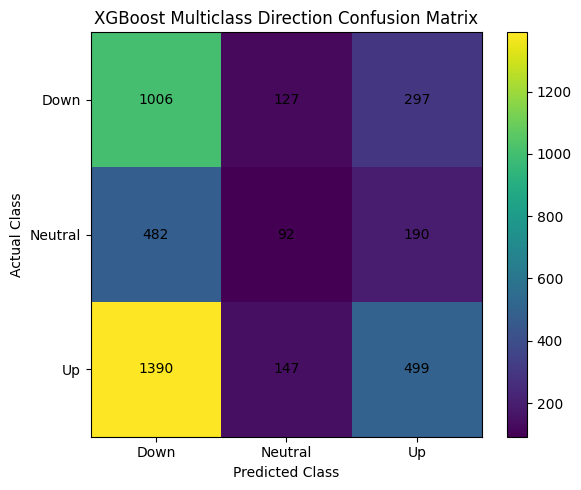

In [10]:
# Plot multiclass confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, aspect="auto")
plt.title("XGBoost Multiclass Direction Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1, 2], ["Down", "Neutral", "Up"])
plt.yticks([0, 1, 2], ["Down", "Neutral", "Up"])
plt.tight_layout()
plt.show()


## 10. Feature Importance

XGBoost provides feature importance values, which help identify which variables influenced the model most.

The chart below shows the average feature importance across all 15 stock-specific models.

In [11]:
# Average feature importance across all stocks
avg_feature_importance = (
    xgboost_feature_importance_df
    .groupby("Feature", as_index=False)["Importance"]
    .mean()
    .sort_values("Importance", ascending=False)
)

avg_feature_importance

,Feature,Importance
3,ma_200,0.061554
4,ma_30,0.059268
8,quarter,0.059031
14,volatility_30,0.055649
5,ma_7,0.055009
6,month,0.054664
17,volume_ma_30,0.053477
1,close_lag_30,0.050452
2,close_lag_7,0.049240
10,return_30d,0.049016


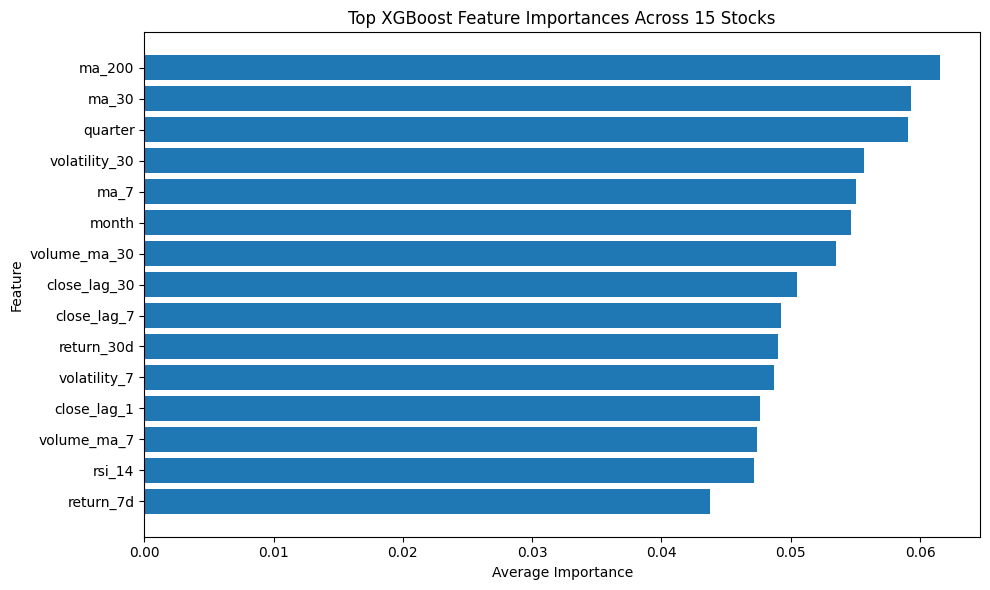

In [12]:
# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    avg_feature_importance["Feature"].head(15)[::-1],
    avg_feature_importance["Importance"].head(15)[::-1]
)

plt.title("Top XGBoost Feature Importances Across 15 Stocks")
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Predicted Return Distribution by Stock

This visualization compares predicted 7-day returns across the 15 stocks.

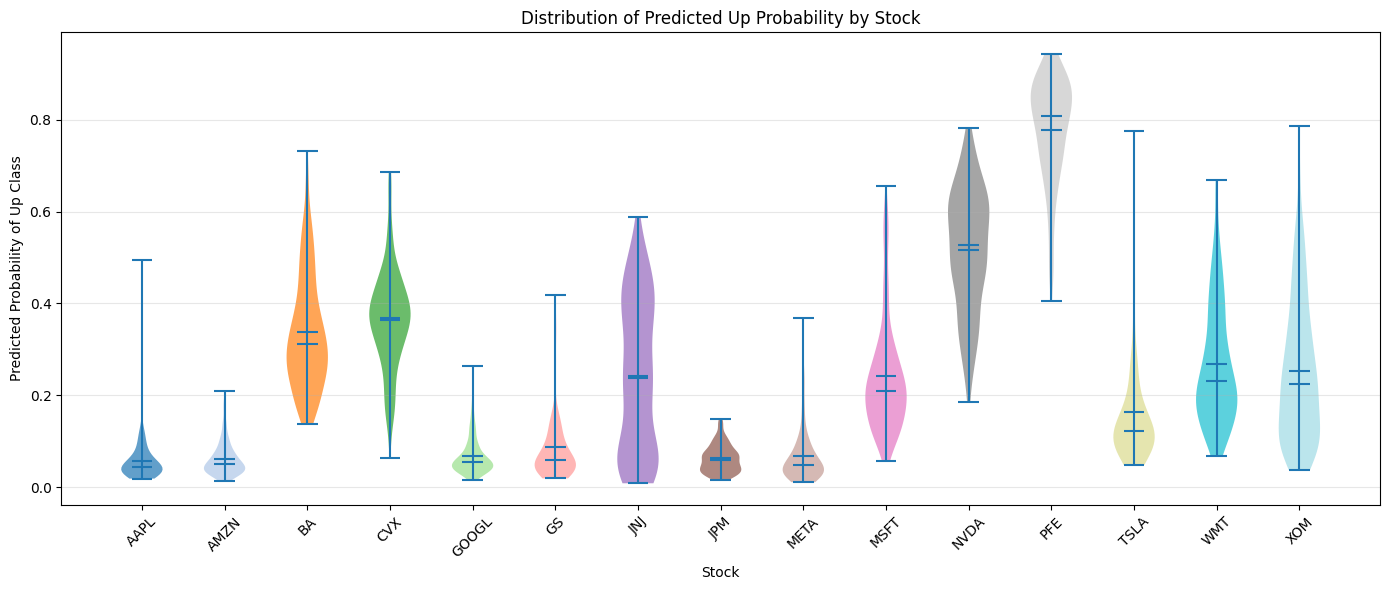

In [13]:
# Prepare data for violin plot using predicted Up probability
stocks = sorted(xgboost_predictions_df["Stock"].unique())
data_to_plot = [
    xgboost_predictions_df[xgboost_predictions_df["Stock"] == stock]["Prob Up"].dropna()
    for stock in stocks
]

plt.figure(figsize=(14, 6))
violin = plt.violinplot(data_to_plot, showmeans=True, showmedians=True)

colors = plt.cm.tab20(np.linspace(0, 1, len(data_to_plot)))
for body, color in zip(violin["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.7)

plt.xticks(np.arange(1, len(stocks) + 1), stocks, rotation=45)
plt.title("Distribution of Predicted Up Probability by Stock")
plt.xlabel("Stock")
plt.ylabel("Predicted Probability of Up Class")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Weekly Stock Rankings

Stocks are ranked by predicted 7-day return for each date.

Rank 1 means the stock has the highest predicted return for that date.

In [14]:
# Rank stocks by classifier ranking score for each date
# Ranking Score = Prob Up - Prob Down
xgboost_predictions_df["Rank"] = xgboost_predictions_df.groupby("Date")[
    "Ranking Score"
].rank(ascending=False, method="first")

# Sort by date and rank
xgboost_predictions_df = xgboost_predictions_df.sort_values(
    ["Date", "Rank"]
).reset_index(drop=True)

xgboost_predictions_df.head(15)


,Date,Stock,Actual 7D Return,Actual Class,Predicted Class,Actual Label,Predicted Label,Prob Down,Prob Neutral,Prob Up,Signal,Ranking Score,Rank
0,2025-01-02,NVDA,-0.047357,0,2,Down,Up,0.276189,0.076759,0.647052,Buy,0.370863,1.0
1,2025-01-02,MSFT,-0.006952,1,1,Neutral,Neutral,0.134361,0.598865,0.266775,Hold,0.132414,2.0
2,2025-01-02,PFE,-0.007516,1,2,Neutral,Up,0.436997,0.072716,0.490287,Buy,0.053289,3.0
3,2025-01-02,BA,-0.028219,0,0,Down,Down,0.371849,0.319711,0.308440,Avoid,-0.063409,4.0
4,2025-01-02,JNJ,0.005069,1,0,Neutral,Down,0.568961,0.086507,0.344532,Avoid,-0.224429,5.0
5,2025-01-02,WMT,0.008778,1,0,Neutral,Down,0.498512,0.249550,0.251938,Avoid,-0.246574,6.0
6,2025-01-02,CVX,0.069457,2,0,Up,Down,0.512073,0.229419,0.258508,Avoid,-0.253566,7.0
7,2025-01-02,TSLA,0.045033,2,0,Up,Down,0.763299,0.096065,0.140636,Avoid,-0.622663,8.0
8,2025-01-02,XOM,0.022458,2,0,Up,Down,0.800701,0.112655,0.086644,Avoid,-0.714057,9.0
9,2025-01-02,JPM,0.031125,2,0,Up,Down,0.810977,0.126899,0.062124,Avoid,-0.748854,10.0


## 13. Most Frequently Top-Ranked Stocks

This chart shows which stocks were most often ranked #1 by the XGBoost model.

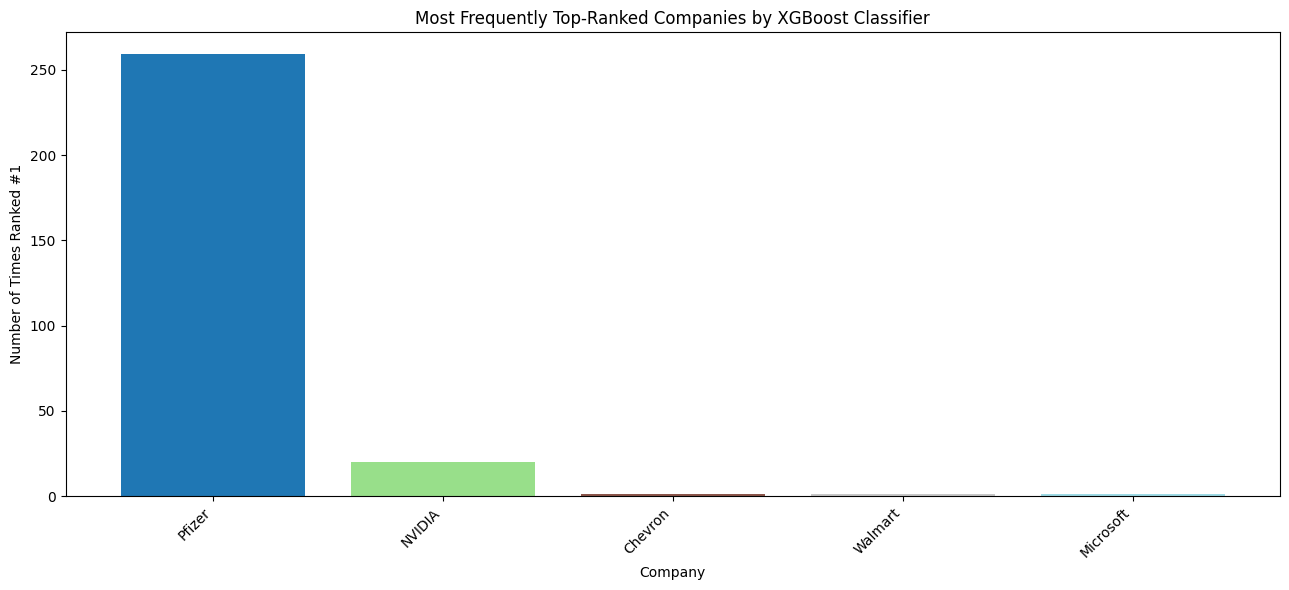

In [15]:
# Select rank 1 stock for each date
top_ranked_xgb = xgboost_predictions_df[
    xgboost_predictions_df["Rank"] == 1
].copy()

# Count top-ranked frequency
top_stock_counts = top_ranked_xgb["Stock"].value_counts()

# Company names for chart labels
company_names = {
    "AAPL": "Apple",
    "AMZN": "Amazon",
    "GOOGL": "Google",
    "MSFT": "Microsoft",
    "NVDA": "NVIDIA",
    "BA": "Boeing",
    "CVX": "Chevron",
    "GS": "Goldman Sachs",
    "JNJ": "Johnson & Johnson",
    "JPM": "JPMorgan Chase",
    "META": "Meta",
    "PFE": "Pfizer",
    "TSLA": "Tesla",
    "WMT": "Walmart",
    "XOM": "Exxon Mobil"
}

company_labels = [company_names.get(stock, stock) for stock in top_stock_counts.index]
colors = plt.cm.tab20(np.linspace(0, 1, len(top_stock_counts)))

plt.figure(figsize=(13, 6))
plt.bar(company_labels, top_stock_counts.values, color=colors)
plt.title("Most Frequently Top-Ranked Companies by XGBoost Classifier")
plt.xlabel("Company")
plt.ylabel("Number of Times Ranked #1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 14. Investment Simulation

This simulation invests in the top-ranked stock for each date and updates the portfolio using the actual realized 7-day return.

The purpose is to test whether the XGBoost ranking output has practical investment value.

In [16]:
# Select top-ranked stock for each date
top_xgb_df = xgboost_predictions_df[
    xgboost_predictions_df["Rank"] == 1
].copy()

# Optional conservative rule:
# Invest only when top stock is predicted as Up. Otherwise hold cash for that date.
top_xgb_df["Strategy Return"] = np.where(
    top_xgb_df["Predicted Class"] == 2,
    top_xgb_df["Actual 7D Return"],
    0
)

# Initial investment amount
initial_capital = 10000
capital = initial_capital

# Store portfolio values
portfolio_values = []

# Update portfolio using actual return of selected top-ranked stock only when signal is Buy
for strategy_return in top_xgb_df["Strategy Return"]:
    capital = capital * (1 + strategy_return)
    portfolio_values.append(capital)

# Store results
top_xgb_df["Portfolio Value"] = portfolio_values
top_xgb_df["Profit/Loss"] = top_xgb_df["Portfolio Value"] - initial_capital

top_xgb_df.head()


,Date,Stock,Actual 7D Return,Actual Class,Predicted Class,Actual Label,Predicted Label,Prob Down,Prob Neutral,Prob Up,Signal,Ranking Score,Rank,Strategy Return,Portfolio Value,Profit/Loss
0,2025-01-02,NVDA,-0.047357,0,2,Down,Up,0.276189,0.076759,0.647052,Buy,0.370863,1.0,-0.047357,9526.426144,-473.573856
15,2025-01-03,NVDA,-0.056967,0,2,Down,Up,0.275617,0.061141,0.663242,Buy,0.387625,1.0,-0.056967,8983.735709,-1016.264291
30,2025-01-06,NVDA,-0.106137,0,2,Down,Up,0.308443,0.083161,0.608396,Buy,0.299953,1.0,-0.106137,8030.232073,-1969.767927
45,2025-01-07,NVDA,-0.017340,0,2,Down,Up,0.312889,0.072638,0.614473,Buy,0.301584,1.0,-0.017340,7890.989430,-2109.010570
60,2025-01-08,PFE,-0.008191,1,2,Neutral,Up,0.294780,0.083724,0.621496,Buy,0.326717,1.0,-0.008191,7826.357350,-2173.642650


In [17]:
# Calculate portfolio summary
final_value = top_xgb_df["Portfolio Value"].iloc[-1]
total_profit = final_value - initial_capital
total_return_pct = (final_value / initial_capital - 1) * 100

print("Initial Capital:", initial_capital)
print("Final Portfolio Value:", round(final_value, 2))
print("Total Profit/Loss:", round(total_profit, 2))
print("Total Return (%):", round(total_return_pct, 2))

Initial Capital: 10000
Final Portfolio Value: 17349.71
Total Profit/Loss: 7349.71
Total Return (%): 73.5


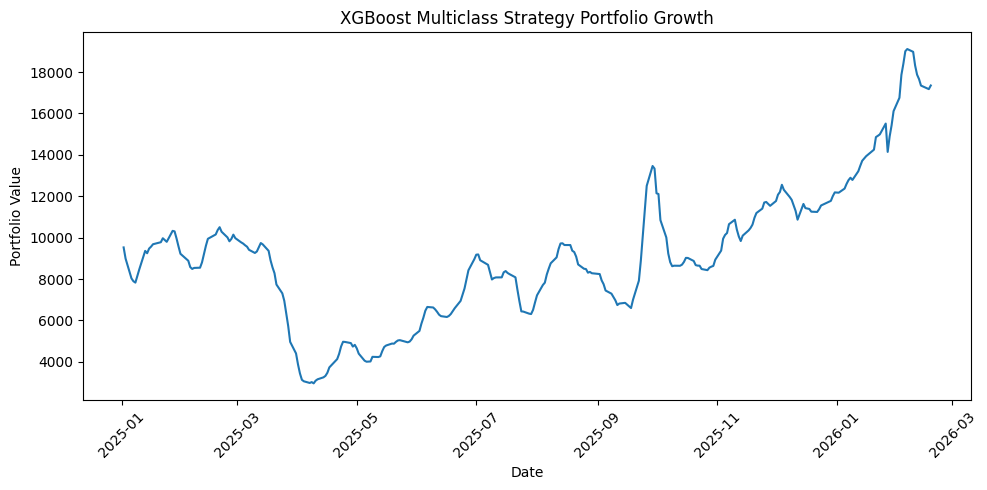

In [18]:
# Plot portfolio growth
plt.figure(figsize=(10, 5))
plt.plot(top_xgb_df["Date"], top_xgb_df["Portfolio Value"])
plt.title("XGBoost Multiclass Strategy Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 15. Save Final XGBoost Outputs

The final files are saved so they can be used in the final project comparison with Elastic Net Logistic, ARIMA, and LSTM.

In [19]:
# Save prediction and metrics outputs
xgboost_predictions_df.to_csv("xgboost_multiclass_predictions_15_stocks.csv", index=False)
xgboost_metrics_df.to_csv("xgboost_multiclass_metrics_15_stocks.csv", index=False)
xgboost_feature_importance_df.to_csv("xgboost_multiclass_feature_importance_15_stocks.csv", index=False)
top_xgb_df.to_csv("xgboost_multiclass_top_ranked_portfolio.csv", index=False)

print("Saved corrected XGBoost multiclass output files successfully.")


Saved corrected XGBoost multiclass output files successfully.


## XGBoost Multiclass Model Methodology

### Objective
The objective of the corrected XGBoost model is to predict the **future 7-day movement class** for each stock rather than directly predicting a numeric return.

### Why This Correction Was Needed
The previous model used `XGBRegressor` to estimate future return and then converted the output into a binary up/down direction using a zero cutoff. That made the classification result unstable because very small returns near zero were treated as real signals.

The corrected model uses `XGBClassifier` and defines three movement classes using a return threshold:

- **Down:** future 7-day return is less than or equal to -1%.
- **Neutral:** future 7-day return is between -1% and +1%.
- **Up:** future 7-day return is greater than or equal to +1%.

### Model Design
The model uses technical indicators, lagged returns, moving averages, volatility, volume ratios, RSI, calendar features, and market index returns from the S&P 500 and Nasdaq.

### Evaluation
The model is evaluated using accuracy, balanced accuracy, macro precision, macro recall, and macro F1 score. Balanced accuracy and macro F1 are important because normal accuracy can be misleading when one class dominates. The notebook also compares the model against naive baselines, including always predicting the majority class and always predicting Up.

### Portfolio Ranking
For portfolio ranking, the model uses:

`Ranking Score = Probability of Up - Probability of Down`

This ranking method is more suitable for the classifier than ranking by a forced regression output.
